# ADRMiner — Embedding-based CatBoost Baseline

## Purpose

This notebook implements the **traditional supervised-classification baseline** used in
the ADRMiner study. It evaluates whether document embeddings combined with a
gradient-boosting classifier are sufficient to classify Architecture Decision Records
(ADRs) according to:

- Kruchten's architectural decision ontology;
- quality attributes; and
- Zimmermann's decision categories.

The baseline uses the manually annotated samples distributed with the artifact. For each
framework, the notebook:

1. converts complete ADR texts into document embeddings;
2. visualizes class frequencies and embedding-space separability;
3. creates a stratified train/test split;
4. trains a class-balanced `CatBoostClassifier`; and
5. reports classification metrics, confusion matrices, Matthews correlation, and
   Cohen's kappa.

## Relation to the companion paper

This notebook supports the methodological comparison between conventional
embedding-based classification and prompt-based classification. It is a baseline and is
not used to generate the full-corpus taxonomy results reported in the paper.

## Main inputs

- `../sample/kruchten_gt_processed1_checked1.csv`
- `../sample/qas_gt_processed1_checked1.csv`
- `../sample/zimmermann_gt_processed1.csv`

## Main outputs

- cached framework-specific embedding matrices under `../sample/`;
- target-frequency and UMAP plots;
- classification reports and confusion matrices; and
- MCC and Cohen's kappa values for each framework.

> **Path assumption:** Run this notebook from the repository's `notebooks/` directory.

## 1. Imports

The following cell imports the embedding, classification, evaluation, and visualization
dependencies used throughout the baseline.

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import OpenAIEmbeddings
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from adr_classification import (
    KruchtenEnum,
    QualityAttributesEnum,
    ZimmermannEnum,
)
import utils


## 2. Configuration

The default configuration uses the local `all-MiniLM-L6-v2` sentence-transformer model,
which requires no API key.

To use OpenAI embeddings instead, configure the repository `.env` file:

```text
EMBEDDING_PROVIDER=openai
OPENAI_API_KEY=your-api-key
OPENAI_EMBEDDINGS_MODEL=text-embedding-3-small
```

For the local default:

```text
EMBEDDING_PROVIDER=huggingface
HUGGINGFACE_EMBEDDINGS_MODEL=all-MiniLM-L6-v2
```

### Embedding cache

Each taxonomy uses a distinct embedding-cache file. This avoids accidentally reusing an
embedding matrix generated from another manually annotated sample.

- `FORCE_RECOMPUTE_EMBEDDINGS = False` reuses a compatible cached matrix.
- `FORCE_RECOMPUTE_EMBEDDINGS = True` regenerates and overwrites the cache.

The notebook also regenerates a cache automatically if its row count does not match the
current sample.

In [2]:
# Load optional configuration from the repository's .env file.
load_dotenv()

True

In [3]:
# ------------------------------------------------------------------
# Embedding configuration
# ------------------------------------------------------------------

EMBEDDING_PROVIDER = os.getenv(
    'EMBEDDING_PROVIDER',
    'huggingface',
).strip().lower()

HUGGINGFACE_EMBEDDINGS_MODEL = os.getenv(
    'HUGGINGFACE_EMBEDDINGS_MODEL',
    'all-MiniLM-L6-v2',
)
OPENAI_EMBEDDINGS_MODEL = os.getenv(
    'OPENAI_EMBEDDINGS_MODEL',
    'text-embedding-3-small',
)

# Recompute cached embeddings even when a compatible file exists.
FORCE_RECOMPUTE_EMBEDDINGS = False

In [4]:
# ------------------------------------------------------------------
# Reproducible classifier configuration
# ------------------------------------------------------------------

TEST_SIZE = 0.25
RANDOM_STATE = 42
CATBOOST_ITERATIONS = 250

# Ground-truth datasets.
KRUCHTEN_GROUND_TRUTH = Path(
    '../sample/kruchten_gt_processed1_checked1.csv'
)
QAS_GROUND_TRUTH = Path(
    '../sample/qas_gt_processed1_checked1.csv'
)
ZIMMERMANN_GROUND_TRUTH = Path(
    '../sample/zimmermann_gt_processed1.csv'
)

EMBEDDING_CACHE_DIR = Path('../sample')
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Embedding provider:', EMBEDDING_PROVIDER)
print('Force embedding recomputation:', FORCE_RECOMPUTE_EMBEDDINGS)
print('CatBoost iterations:', CATBOOST_ITERATIONS)

Embedding provider: huggingface
Force embedding recomputation: False
CatBoost iterations: 250


In [5]:
# Initialize the selected document-embedding model.
if EMBEDDING_PROVIDER == 'huggingface':
    EMBEDDING_MODEL_NAME = HUGGINGFACE_EMBEDDINGS_MODEL
    embeddings_model = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL_NAME,
    )

elif EMBEDDING_PROVIDER == 'openai':
    api_key = os.getenv('OPENAI_API_KEY')
    if not api_key:
        raise EnvironmentError(
            'OPENAI_API_KEY is required when '
            "EMBEDDING_PROVIDER='openai'."
        )

    EMBEDDING_MODEL_NAME = OPENAI_EMBEDDINGS_MODEL
    embeddings_model = OpenAIEmbeddings(
        model=EMBEDDING_MODEL_NAME,
        api_key=api_key,
    )

else:
    raise ValueError(
        f"Unsupported EMBEDDING_PROVIDER={EMBEDDING_PROVIDER!r}. "
        "Use 'huggingface' or 'openai'."
    )

print('Embedding model:', EMBEDDING_MODEL_NAME)

Embedding model: all-MiniLM-L6-v2


In [6]:
print('Kruchten sample:', KRUCHTEN_GROUND_TRUTH)
print('Quality-attribute sample:', QAS_GROUND_TRUTH)
print('Zimmermann sample:', ZIMMERMANN_GROUND_TRUTH)
print('Embedding cache directory:', EMBEDDING_CACHE_DIR)

Kruchten sample: ..\sample\kruchten_gt_processed1_checked1.csv
Quality-attribute sample: ..\sample\qas_gt_processed1_checked1.csv
Zimmermann sample: ..\sample\zimmermann_gt_processed1.csv
Embedding cache directory: ..\sample


## 3. Shared helper functions

The helper functions below load annotated samples, cache embeddings, prepare encoded
targets, split the data, train CatBoost, and compute the shared evaluation metrics.
Centralizing this logic ensures that all three taxonomies are evaluated consistently.

In [7]:
def slugify(value: str) -> str:
    """Convert a model name into a filename-safe identifier."""
    return re.sub(
        r'[^a-zA-Z0-9._-]+',
        '-',
        value,
    ).strip('-').lower()


def load_ground_truth(path: Path) -> pd.DataFrame:
    """Load and validate one manually annotated ADR sample."""
    if not path.is_file():
        raise FileNotFoundError(
            f'Ground-truth file was not found: {path}'
        )

    df = pd.read_csv(path, sep=';').dropna(
        subset=['human', 'ADR', 'raw_text']
    )

    print('Sample shape:', df.shape)
    print(
        'Human categories:',
        len(df['human'].unique()),
        sorted(df['human'].unique()),
    )

    if 'primary_category' in df.columns:
        print(
            'Existing model categories:',
            len(df['primary_category'].dropna().unique()),
            sorted(df['primary_category'].dropna().unique()),
        )

    return df


def embedding_cache_path(framework_name: str) -> Path:
    """Return a taxonomy- and model-specific embedding-cache path."""
    provider_model = slugify(
        f'{EMBEDDING_PROVIDER}-{EMBEDDING_MODEL_NAME}'
    )
    return EMBEDDING_CACHE_DIR / (
        f'{framework_name}_raw_text_embeddings_{provider_model}.csv'
    )


def load_or_compute_embeddings(
    sentences,
    framework_name: str,
):
    """Load compatible cached embeddings or compute and store them."""
    cache_path = embedding_cache_path(framework_name)
    file_exists = cache_path.is_file()

    should_recompute = (
        FORCE_RECOMPUTE_EMBEDDINGS
        or not file_exists
    )

    embeddings_df = None
    if file_exists and not FORCE_RECOMPUTE_EMBEDDINGS:
        embeddings_df = pd.read_csv(cache_path)

        if len(embeddings_df) != len(sentences):
            print(
                'Cached row count does not match the current sample; '
                'embeddings will be regenerated.'
            )
            should_recompute = True

    if should_recompute:
        if FORCE_RECOMPUTE_EMBEDDINGS and file_exists:
            print(
                'FORCE_RECOMPUTE_EMBEDDINGS is enabled; '
                'the cached matrix will be overwritten.'
            )

        print('Computing embeddings:', cache_path)
        embeddings = embeddings_model.embed_documents(
            list(sentences)
        )
        embeddings_df = pd.DataFrame(embeddings)
        embeddings_df.to_csv(cache_path, index=False)
    else:
        print('Loading cached embeddings:', cache_path)

    embeddings = embeddings_df.to_numpy()
    print('Embedding-matrix dimensions:', embeddings_df.shape)
    return embeddings_df, embeddings


def prepare_features_and_targets(
    df_gt: pd.DataFrame,
    enum_class,
):
    """Embed ADRs and encode their human-assigned target labels."""
    labels = sorted(str(member.value) for member in enum_class)
    print('Framework labels:', len(labels), labels)

    framework_name = enum_class.__name__.replace(
        'Enum',
        '',
    ).lower()

    embeddings_df, embeddings = load_or_compute_embeddings(
        df_gt['raw_text'].tolist(),
        framework_name=framework_name,
    )

    label_encoder = LabelEncoder()
    label_encoder.fit(labels)
    target = label_encoder.transform(
        df_gt['human'].values
    )

    X = embeddings_df.copy()
    y = pd.Series(target, name='target')

    return (
        X,
        y,
        embeddings,
        label_encoder,
    )


def train_catboost_baseline(X, y):
    """Train a class-balanced CatBoost model on a stratified split."""
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    observed_classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=observed_classes,
        y=y_train,
    )
    class_weights_dict = dict(
        zip(observed_classes, class_weights)
    )

    classifier = CatBoostClassifier(
        iterations=CATBOOST_ITERATIONS,
        loss_function='MultiClass',
        class_weights=class_weights_dict,
        verbose=False,
        random_seed=RANDOM_STATE,
    )
    classifier.fit(X_train, y_train)

    y_pred = np.asarray(
        classifier.predict(X_test)
    ).reshape(-1).astype(int)

    return (
        classifier,
        X_test,
        y_test,
        y_pred,
        class_weights_dict,
    )


def evaluate_predictions(
    classifier,
    X,
    y,
    y_test,
    y_pred,
    label_encoder,
    title: str,
):
    """Compute and display the shared baseline metrics."""
    observed_test_labels = sorted(
        set(y_test).union(set(y_pred))
    )
    observed_class_names = list(
        label_encoder.inverse_transform(
            observed_test_labels
        )
    )

    report = classification_report(
        y_test,
        y_pred,
        labels=observed_test_labels,
        target_names=observed_class_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=observed_test_labels,
    )
    cm_df = pd.DataFrame(
        cm,
        index=observed_class_names,
        columns=observed_class_names,
    )

    precision, recall, fscore, support = (
        precision_recall_fscore_support(
            y_test,
            y_pred,
            labels=observed_test_labels,
            average=None,
            zero_division=0,
        )
    )

    print('Metrics per observed test class:')
    for index, class_name in enumerate(observed_class_names):
        print(
            f'  {class_name}: '
            f'precision={precision[index]:.4f}, '
            f'recall={recall[index]:.4f}, '
            f'F1={fscore[index]:.4f}, '
            f'support={support[index]}'
        )

    for average in ['macro', 'weighted', 'micro']:
        avg_precision, avg_recall, avg_fscore, _ = (
            precision_recall_fscore_support(
                y_test,
                y_pred,
                average=average,
                zero_division=0,
            )
        )
        print(
            f'{average.capitalize()} — '
            f'precision={avg_precision:.4f}, '
            f'recall={avg_recall:.4f}, '
            f'F1={avg_fscore:.4f}'
        )

    accuracy = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    test_kappa = cohen_kappa_score(y_test, y_pred)

    y_pred_all = np.asarray(
        classifier.predict(X)
    ).reshape(-1).astype(int)
    all_kappa = cohen_kappa_score(y, y_pred_all)

    print(f'Accuracy (test): {accuracy:.4f}')
    print(f'Matthews coefficient (test): {mcc:.4f}')
    print(f"Cohen's kappa (test): {test_kappa:.4f}")
    print(f"Cohen's kappa (all data): {all_kappa:.4f}")

    utils.show_classification_report(
        report,
        title=title,
    )
    utils.show_confusion_matrix(
        cm_df,
        title=title,
        normalized=True,
    )
    utils.show_classification_mosaic(
        cm,
        cm_labels=observed_class_names,
        title=title,
        figsize=(8, 8),
    )

    return {
        'report': report,
        'confusion_matrix': cm_df,
        'accuracy': accuracy,
        'matthews': mcc,
        'kappa_test': test_kappa,
        'kappa_all': all_kappa,
    }

## 4. Kruchten's architectural decision ontology

This section evaluates the embedding-based baseline for the four Kruchten categories:
Existence, Ban/Non-existence, Property, and Executive.

In [8]:
kruchten_df = load_ground_truth(
    KRUCHTEN_GROUND_TRUTH
)
kruchten_df.head()


Sample shape: (200, 10)
Human categories: 4 ['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Existence (ontocrisis)', 'Property (diacrisis)']
Existing model categories: 4 ['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Existence (ontocrisis)', 'Property (diacrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,human_old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Executive (pericrisis),Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),Executive (pericrisis),1.0,# Cutting release branch does not create a set...


In [9]:
(
    X,
    y,
    embeddings,
    label_encoder,
) = prepare_features_and_targets(
    kruchten_df,
    KruchtenEnum,
)


Framework labels: 4 ['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Existence (ontocrisis)', 'Property (diacrisis)']
Loading cached embeddings: ..\sample\kruchten_raw_text_embeddings_huggingface-all-minilm-l6-v2.csv
Embedding-matrix dimensions: (200, 384)


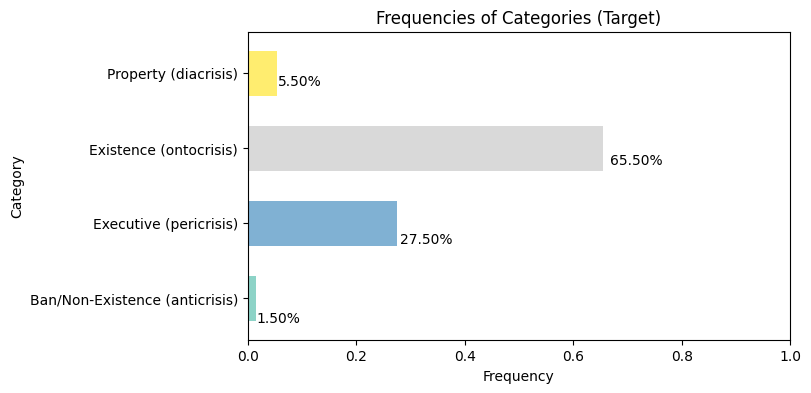

In [10]:
# Inspect class imbalance before training.
_ = utils.show_target_frequencies(
    kruchten_df['human']
)


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ban/Non-Existence (anticrisis) 3
Executive (pericrisis) 55
Existence (ontocrisis) 131
Property (diacrisis) 11


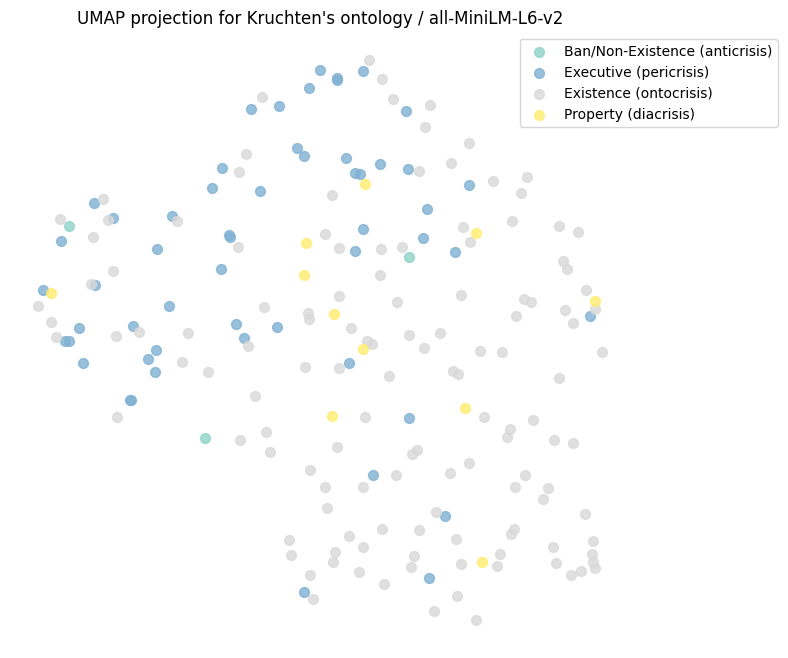

In [11]:
# Qualitative view of class separability in the embedding space.
_ = utils.show_umap_projection(
    kruchten_df['human'],
    embeddings,
    title=(
        "UMAP projection for Kruchten's ontology / "
        + EMBEDDING_MODEL_NAME
    ),
    alpha=0.8,
)


In [12]:
(
    classifier,
    X_test,
    y_test,
    y_pred,
    class_weights_dict,
) = train_catboost_baseline(X, y)

print('Class weights:', class_weights_dict)


Class weights: {0: 18.75, 1: 0.8928571428571429, 2: 0.3826530612244898, 3: 4.6875}


Metrics per observed test class:
  Ban/Non-Existence (anticrisis): precision=0.0000, recall=0.0000, F1=0.0000, support=1
  Executive (pericrisis): precision=0.7500, recall=0.4615, F1=0.5714, support=13
  Existence (ontocrisis): precision=0.7619, recall=0.9697, F1=0.8533, support=33
  Property (diacrisis): precision=0.0000, recall=0.0000, F1=0.0000, support=3
Macro — precision=0.3780, recall=0.3578, F1=0.3562
Weighted — precision=0.6979, recall=0.7600, F1=0.7118
Micro — precision=0.7600, recall=0.7600, F1=0.7600
Accuracy (test): 0.7600
Matthews coefficient (test): 0.4506
Cohen's kappa (test): 0.4059
Cohen's kappa (all data): 0.8724


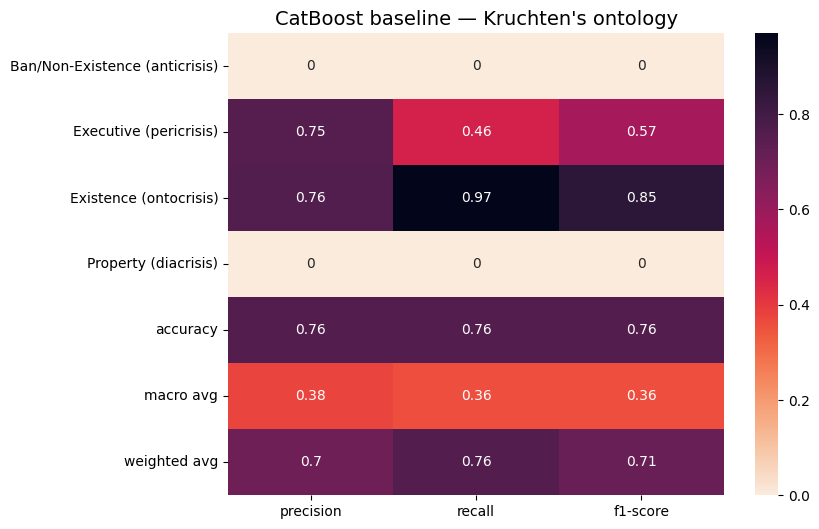

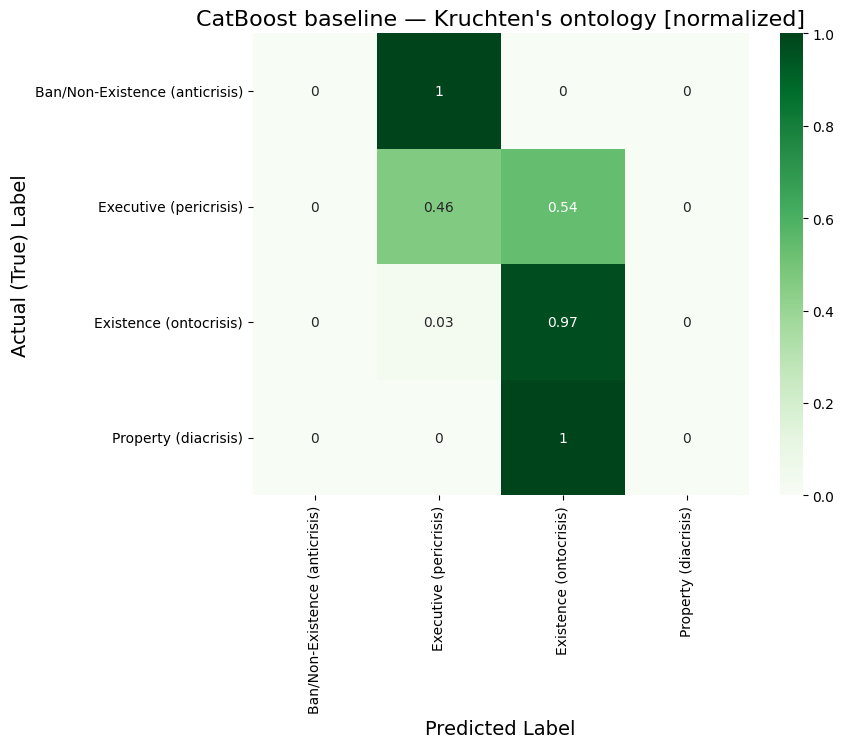

All colors: 64 classes: 4 mosaic tuples: 16


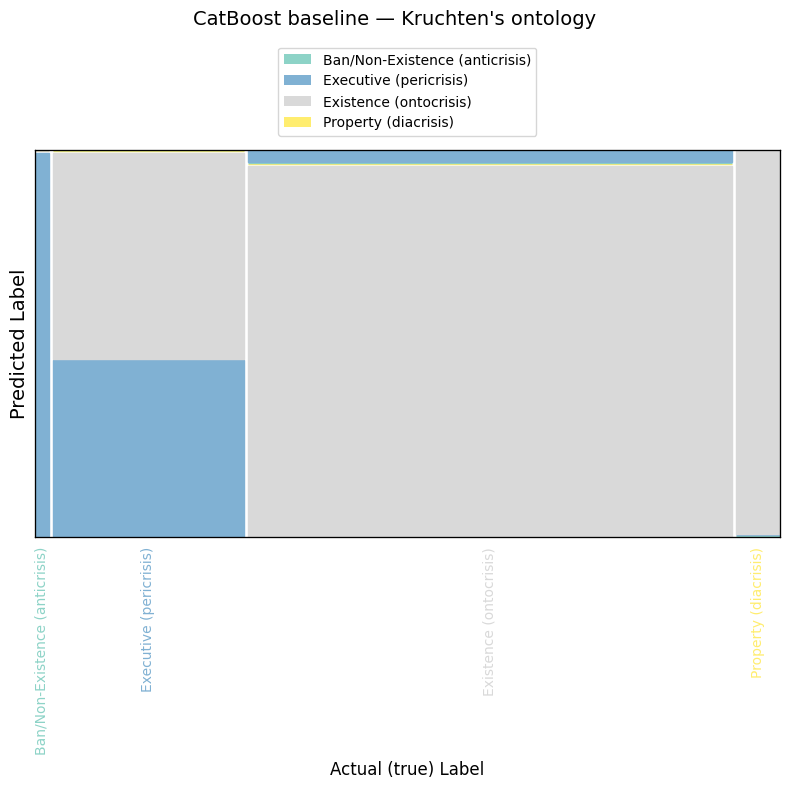

In [13]:
kruchten_metrics = evaluate_predictions(
    classifier=classifier,
    X=X,
    y=y,
    y_test=y_test,
    y_pred=y_pred,
    label_encoder=label_encoder,
    title="CatBoost baseline — Kruchten's ontology",
)


---

## 5. Quality-attribute classification

This section evaluates the baseline over the quality-attribute labels represented in the
manually annotated sample. The larger number of classes and class imbalance make this a
particularly challenging setting.

In [14]:
qas_df = load_ground_truth(
    QAS_GROUND_TRUTH
)
qas_df.head()


Sample shape: (200, 10)
Human categories: 11 ['Compatibility', 'Maintainability', 'Observability', 'Other/Only Functional Concern', 'Performance', 'Portability', 'Reliability', 'Scalability', 'Security', 'Testability', 'Usability']
Existing model categories: 11 ['Compatibility', 'Maintainability', 'Observability', 'Other/Only Functional Concern', 'Performance', 'Portability', 'Reliability', 'Scalability', 'Security', 'Testability', 'Usability']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Human-old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Maintainability,The ADR discusses implementing an architectura...,"0,75",Maintainability,Maintainability,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Maintainability,The ADR discusses using Ansible roles and play...,"0,60",Compatibility,Compatibility,0.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Other/Only Functional Concern,The ADR primarily discusses versioning and rel...,"0,30",Other/Only Functional Concern,Other/Only Functional Concern,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Maintainability,The ADR primarily addresses how configuration ...,"0,75",Maintainability,Maintainability,1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Testability,The ADR primarily discusses procedural and ope...,"0,20",Maintainability,Maintainability,0.0,# Cutting release branch does not create a set...


In [15]:
(
    X,
    y,
    embeddings,
    label_encoder,
) = prepare_features_and_targets(
    qas_df,
    QualityAttributesEnum,
)


Framework labels: 11 ['Compatibility', 'Maintainability', 'Observability', 'Other/Only Functional Concern', 'Performance', 'Portability', 'Reliability', 'Scalability', 'Security', 'Testability', 'Usability']
Loading cached embeddings: ..\sample\qualityattributes_raw_text_embeddings_huggingface-all-minilm-l6-v2.csv
Embedding-matrix dimensions: (200, 384)


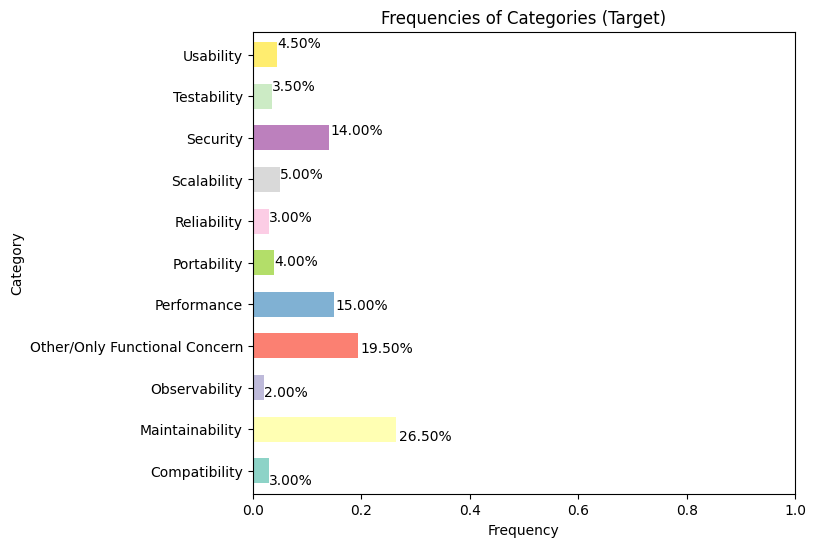

In [16]:
# Inspect class imbalance before training.
_ = utils.show_target_frequencies(
    qas_df['human'],
    figsize=(7, 6),
)


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Compatibility 6
Maintainability 53
Observability 4
Other/Only Functional Concern 39
Performance 30
Portability 8
Reliability 6
Scalability 10
Security 28
Testability 7
Usability 9


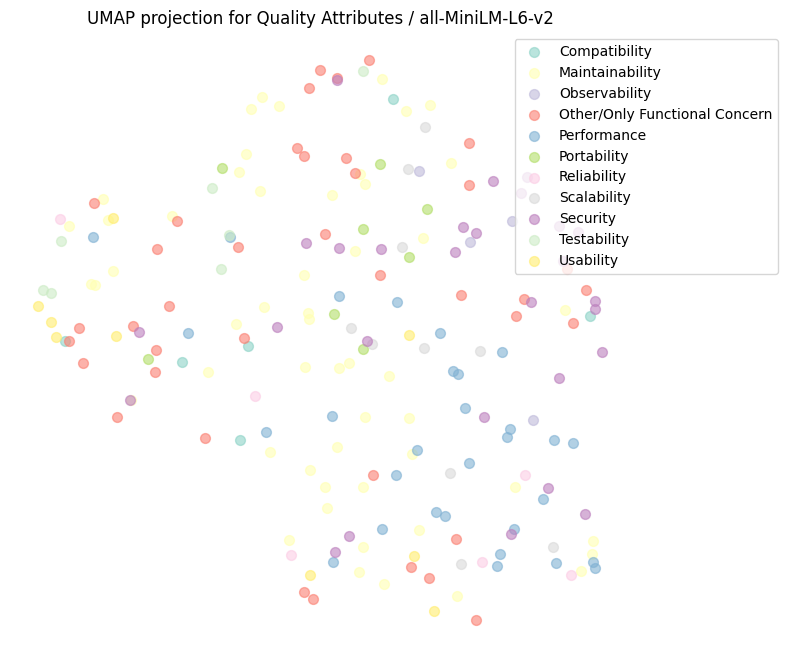

In [17]:
# Qualitative view of class separability in the embedding space.
_ = utils.show_umap_projection(
    qas_df['human'],
    embeddings,
    title=(
        'UMAP projection for Quality Attributes / '
        + EMBEDDING_MODEL_NAME
    ),
)


In [18]:
(
    classifier,
    X_test,
    y_test,
    y_pred,
    class_weights_dict,
) = train_catboost_baseline(X, y)

print('Class weights:', class_weights_dict)


Class weights: {0: 3.409090909090909, 1: 0.3409090909090909, 2: 4.545454545454546, 3: 0.4702194357366771, 4: 0.5928853754940712, 5: 2.272727272727273, 6: 2.727272727272727, 7: 1.948051948051948, 8: 0.6493506493506493, 9: 2.727272727272727, 10: 1.948051948051948}


Metrics per observed test class:
  Compatibility: precision=0.0000, recall=0.0000, F1=0.0000, support=2
  Maintainability: precision=0.3750, recall=0.6923, F1=0.4865, support=13
  Observability: precision=1.0000, recall=1.0000, F1=1.0000, support=1
  Other/Only Functional Concern: precision=0.2000, recall=0.2000, F1=0.2000, support=10
  Performance: precision=0.4545, recall=0.7143, F1=0.5556, support=7
  Portability: precision=0.0000, recall=0.0000, F1=0.0000, support=2
  Reliability: precision=0.0000, recall=0.0000, F1=0.0000, support=1
  Scalability: precision=0.0000, recall=0.0000, F1=0.0000, support=3
  Security: precision=0.2500, recall=0.1429, F1=0.1818, support=7
  Testability: precision=0.0000, recall=0.0000, F1=0.0000, support=2
  Usability: precision=0.0000, recall=0.0000, F1=0.0000, support=2
Macro — precision=0.2072, recall=0.2500, F1=0.2204
Weighted — precision=0.2561, recall=0.3600, F1=0.2897
Micro — precision=0.3600, recall=0.3600, F1=0.3600
Accuracy (test): 0.3600
Matth

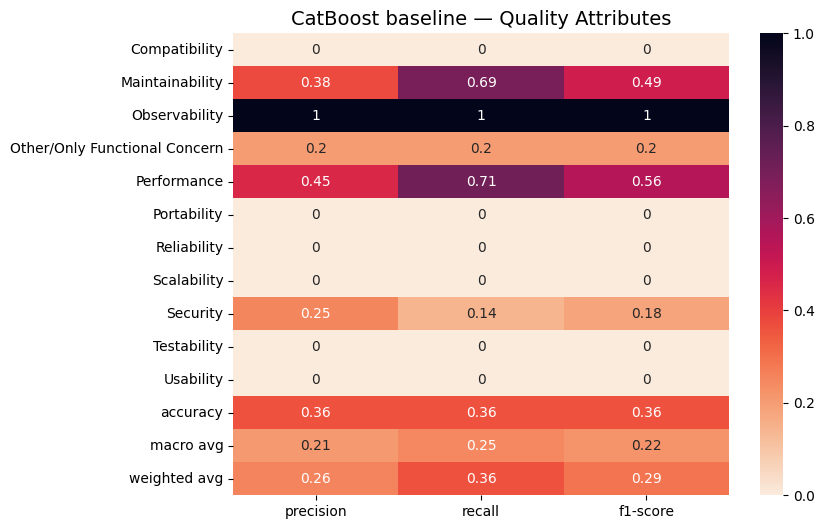

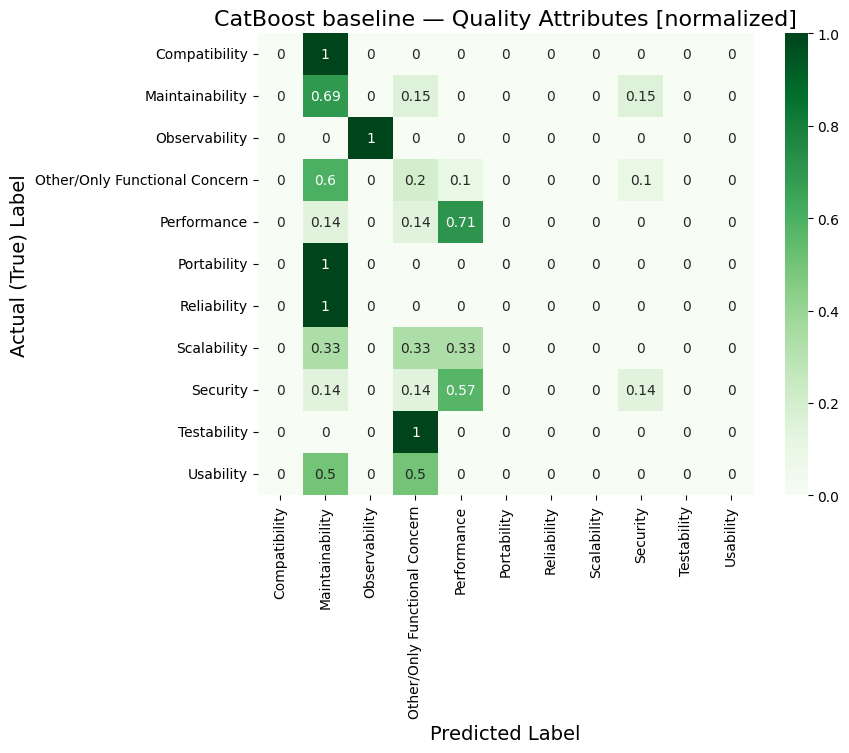

All colors: 1331 classes: 11 mosaic tuples: 121


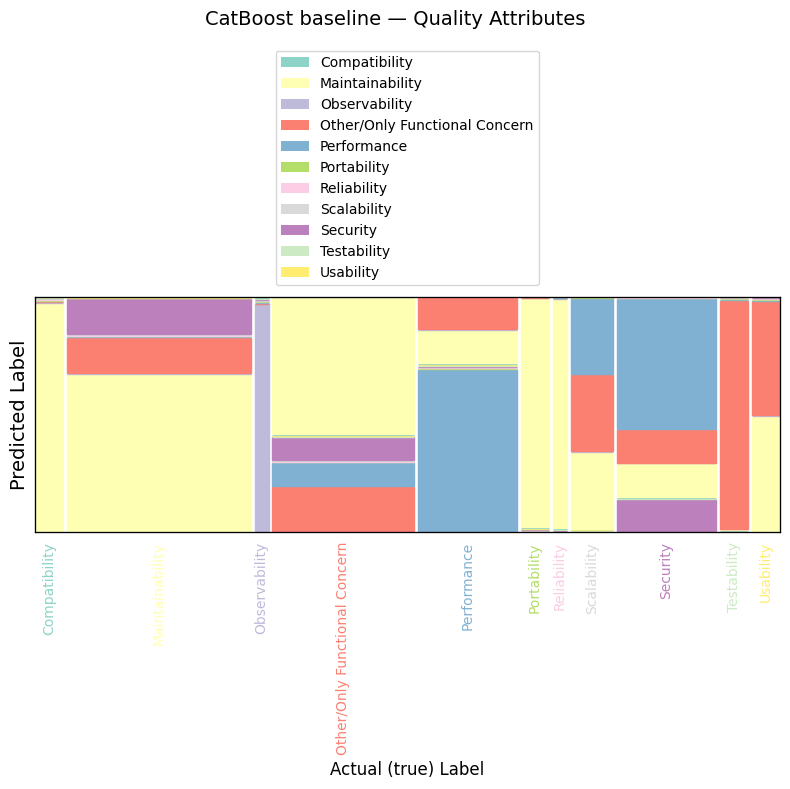

In [19]:
qas_metrics = evaluate_predictions(
    classifier=classifier,
    X=X,
    y=y,
    y_test=y_test,
    y_pred=y_pred,
    label_encoder=label_encoder,
    title='CatBoost baseline — Quality Attributes',
)


---

## 6. Zimmermann's decision categories

This section evaluates the baseline for Zimmermann's categories. Not every category in
the complete framework is necessarily represented in the manually annotated sample;
metrics and confusion matrices are therefore computed over the labels observed in the
test split.

In [20]:
zimmermann_df = load_ground_truth(
    ZIMMERMANN_GROUND_TRUTH
)
zimmermann_df.head()


Sample shape: (200, 9)
Human categories: 8 ['Constraint', 'Crosscutting Concerns', 'Design', 'Implementation', 'Infrastructure', 'Organizational/Process', 'Other', 'Technology']
Existing model categories: 8 ['Constraint', 'Crosscutting Concerns', 'Design', 'Implementation', 'Infrastructure', 'Organizational/Process', 'Other', 'Technology']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Design,The ADR primarily discusses the architectural ...,"0,85",Design,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Infrastructure,The ADR focuses on provisioning and deployment...,"0,70",Infrastructure,1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Technology,The ADR focuses on establishing a versioning a...,"0,75",Technology,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Design,The ADR primarily addresses the organization a...,"0,85",Infrastructure,0.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Technology,The ADR primarily discusses changes to the rel...,"0,60",Technology,1.0,# Cutting release branch does not create a set...


In [21]:
(
    X,
    y,
    embeddings,
    label_encoder,
) = prepare_features_and_targets(
    zimmermann_df,
    ZimmermannEnum,
)


Framework labels: 9 ['Constraint', 'Crosscutting Concerns', 'Design', 'Implementation', 'Infrastructure', 'Organizational/Process', 'Other', 'Quality Attribute', 'Technology']
Loading cached embeddings: ..\sample\zimmermann_raw_text_embeddings_huggingface-all-minilm-l6-v2.csv
Embedding-matrix dimensions: (200, 384)


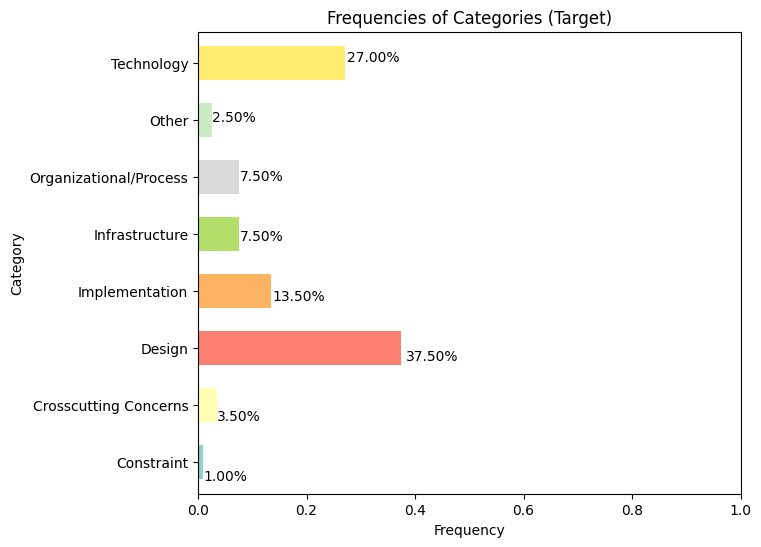

In [22]:
# Inspect class imbalance before training.
zimmermann_colors = utils.show_target_frequencies(
    zimmermann_df['human'],
    figsize=(7, 6),
)


c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\AK128882\anaconda3\envs\adrs\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Constraint 2
Crosscutting Concerns 7
Design 75
Implementation 27
Infrastructure 15
Organizational/Process 15
Other 5
Technology 54


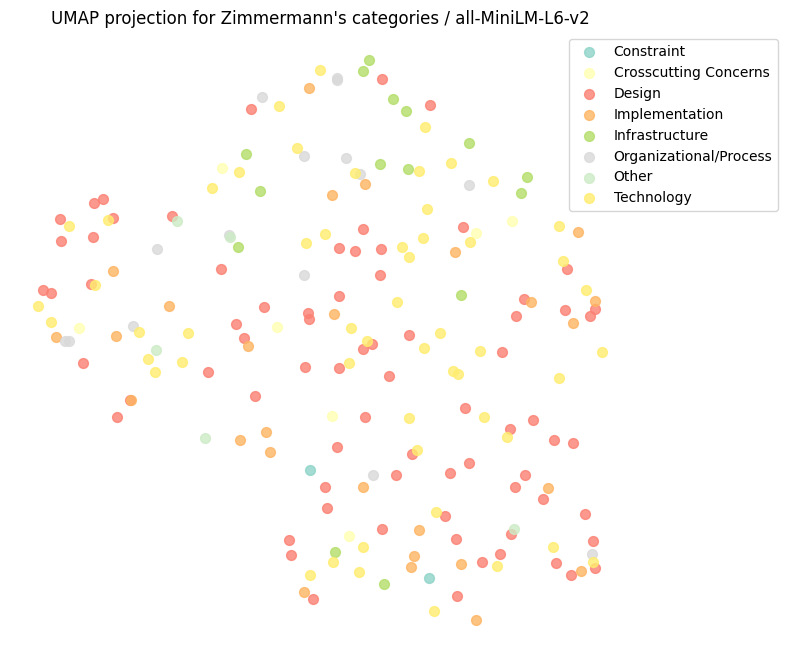

In [23]:
# Qualitative view of class separability in the embedding space.
_ = utils.show_umap_projection(
    zimmermann_df['human'],
    embeddings,
    color_dict=zimmermann_colors,
    alpha=0.8,
    title=(
        "UMAP projection for Zimmermann's categories / "
        + EMBEDDING_MODEL_NAME
    ),
)


In [24]:
(
    classifier,
    X_test,
    y_test,
    y_pred,
    class_weights_dict,
) = train_catboost_baseline(X, y)

print('Class weights:', class_weights_dict)


Class weights: {0: 9.375, 1: 3.75, 2: 0.33482142857142855, 3: 0.9375, 4: 1.7045454545454546, 5: 1.7045454545454546, 6: 4.6875, 8: 0.4573170731707317}


Metrics per observed test class:
  Crosscutting Concerns: precision=0.0000, recall=0.0000, F1=0.0000, support=2
  Design: precision=0.3448, recall=0.5263, F1=0.4167, support=19
  Implementation: precision=0.0000, recall=0.0000, F1=0.0000, support=7
  Infrastructure: precision=1.0000, recall=0.2500, F1=0.4000, support=4
  Organizational/Process: precision=0.0000, recall=0.0000, F1=0.0000, support=4
  Other: precision=0.0000, recall=0.0000, F1=0.0000, support=1
  Technology: precision=0.1667, recall=0.2308, F1=0.1935, support=13
Macro — precision=0.2159, recall=0.1439, F1=0.1443
Weighted — precision=0.2544, recall=0.2800, F1=0.2407
Micro — precision=0.2800, recall=0.2800, F1=0.2800
Accuracy (test): 0.2800
Matthews coefficient (test): -0.0651
Cohen's kappa (test): -0.0607
Cohen's kappa (all data): 0.7554


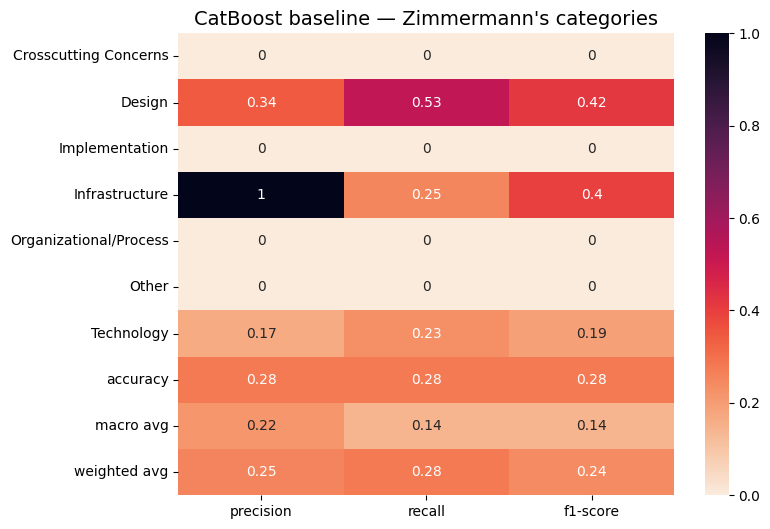

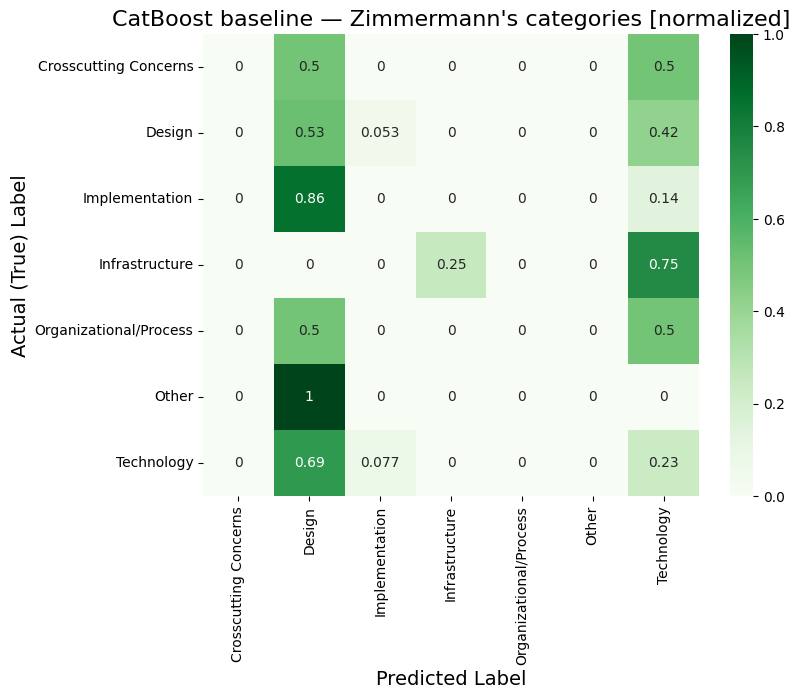

All colors: 343 classes: 7 mosaic tuples: 49


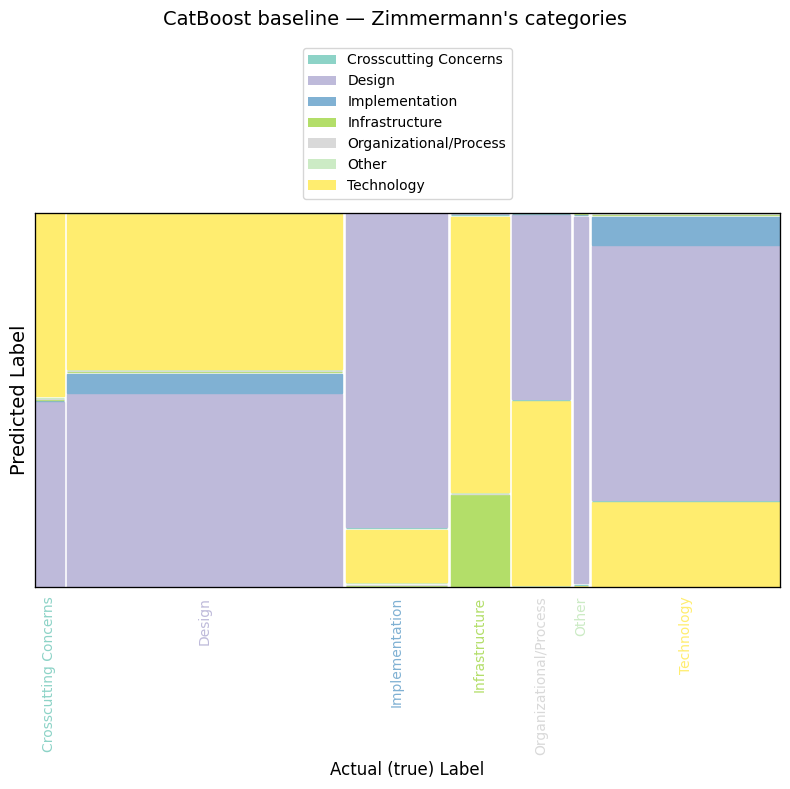

In [25]:
zimmermann_metrics = evaluate_predictions(
    classifier=classifier,
    X=X,
    y=y,
    y_test=y_test,
    y_pred=y_pred,
    label_encoder=label_encoder,
    title="CatBoost baseline — Zimmermann's categories",
)


---

## 7. Interpreting the baseline

The UMAP plots provide a qualitative view of whether ADR embeddings form distinct
taxonomy-specific clusters. The classification metrics provide the quantitative
evaluation.

Limited performance should not be interpreted as evidence that document embeddings are
unsuitable for all ADR analyses. Embeddings remain useful for semantic similarity,
retrieval, topic modeling, and dynamic few-shot selection. This baseline specifically
tests whether a single document-level embedding contains enough information to separate
categories defined by the **purpose or architectural intent** of an ADR.

## 8. Expected artifacts and reuse

After running the notebook, users should obtain one embedding cache and one set of
evaluation outputs for each taxonomy.

To repeat the experiment with another embedding model:

1. update `EMBEDDING_PROVIDER` and the corresponding model variable;
2. keep `FORCE_RECOMPUTE_EMBEDDINGS = True` for the first run; and
3. compare the resulting UMAP projections and classification metrics.

The cache filenames include both the taxonomy and embedding-model identifier, so
experiments with different models can coexist without overwriting one another.